# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 07   |  |
| :-------------|:-------------|
| Jesse Dijkzeul | 6542956 |
| Pim van Beers | 6542026 |
| Eline Deiters | 6283136 |
| Planning Groep: 07     |Tijdstip / Tijdspanne  |
| Eerste twee sanity checks maken/afronden | 11:15 - 11:30 |
| Ontwerpen en maken condensator | 11:30 - 12:30 |
| Lunch Pauze | 12:30 - 13:30 |
| Berekenen / meten van de capaciteit van de condensator | 13:30 - 14:00 |
| Bedenken van een sensor toepassing | 14:00 - 14:30 |
| Maken sensor | 14:30 - 15:30 |
| Kalibratie met arduino | 15:30 - 16:30 |
| Opruimen inleveren etc. | 16:30 - 17:30 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="Foto schets condensator.jpeg" alt="schets student 1" width="400"/>

In [6]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

import numpy as np

def vlakkeplaat(A, epsilon_r, d):
    epsilon0 = 8.854e-12
    C = epsilon0 * epsilon_r * A / d
    return C

def bereken_voltage(R,C,f,A):
    V = C * R * A * 2 * np.pi * f
    return V

def bereken_capaciteit(V, R, f, A):
    C = V / (R * A * 2 * np.pi * f)
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.
# Test

In [7]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.
epsilon_r_karton = 3
A = 0.1 * 0.1
d = 0.002
C = vlakkeplaat(A, epsilon_r_karton, d) * 1e12


print(f"Berekende capaciteit plaatcondensator groep 07 is {C:.1f} pF")
print(f"Berekende voltage plaatcondensator groep 07 is {bereken_voltage(1000, C * 1e-12, 100e3, 8):.2f} V")
print(f"Gemeten voltage plaatcondensator groep 07 is {0.76} V")
print(f"Gemeten capaciteit plaatcondensator groep 07 is {(bereken_capaciteit(3.8 * 0.2, 1000, 100e3, 8) * 1e12):.1f} pF")




Berekende capaciteit plaatcondensator groep 07 is 132.8 pF
Berekende voltage plaatcondensator groep 07 is 0.67 V
Gemeten voltage plaatcondensator groep 07 is 0.76 V
Gemeten capaciteit plaatcondensator groep 07 is 151.2 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
<img src="Foto condensator.jpeg" alt="schets student 1" width="400"/>
<img src="Foto meetopstelling.jpeg" alt="schets student 1" width="400"/>
<img src="Foto meetwaardes.jpeg" alt="schets student 1" width="400"/>

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 07 | 132.8 pF | 0.67 V | 0.76 V | 151.2 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
1. Krachtmeter
<img src="Schets Krachtmeter: Weegschaal, Ontwerpopdracht2.jpeg" alt="schets student 1" width="400"/>
2. Luchtdruksensor
<img src="Schets Luchtdruksensor, Ontwerpopdracht 2.jpeg" alt="schets student 1" width="400"/>
3. Thermometer
<img src="Schets Thermometer, Ontwerpopdracht2.jpeg" alt="schets student 1" width="400"/>

## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een krachtsensor maken.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](tudelftLogo.png)

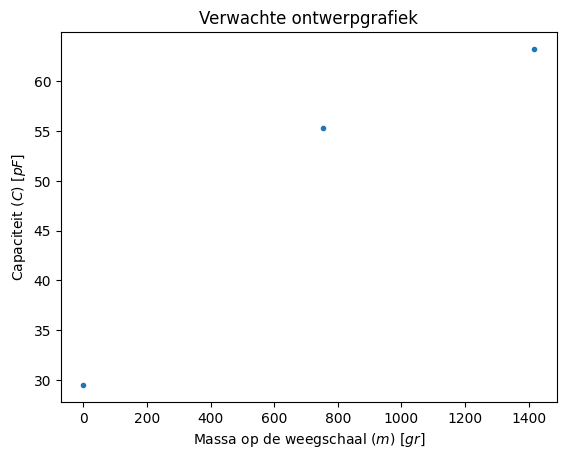

[29.51333333 55.3375     63.24285714]


In [52]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.

# Bij de volgende berekeningen gaan wij ervanuit dat de afstand tussen de platen van de condensator 
# liniear afneemt naarmaten het gewicht liniear toeneemt

import matplotlib.pyplot as plt

m = np.array([0., 754., 1418.])

d = np.array([3, 1.6, 1.4]) / 1000

A = 0.01

Amplitude = 8

f = 100e3

R = 1000

epsilon_r = 1

C = vlakkeplaat(A, epsilon_r, d)

V = bereken_voltage(R, C, f, Amplitude) * 1000

plt.figure()
plt.plot(m, C * 1e12, '.')
plt.xlabel(r"Massa op de weegschaal ($m$) [$gr$]")
plt.ylabel(r"Capaciteit ($C$) [$pF$]")
plt.title("Verwachte ontwerpgrafiek")
plt.show()

print(C *1e12)





## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 14.8 | 74 |
| gemiddelde capaciteit| 23.9 | 119 |
| maximale capaciteit| 31.6 | 157 |
## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
<img src="Meeting 1.JPG" alt="schets student 1" width="400"/>
<img src="Meeting 2.JPG" alt="schets student 1" width="400"/>

## Opdracht 7: Plot de kalibratiegrafiek.

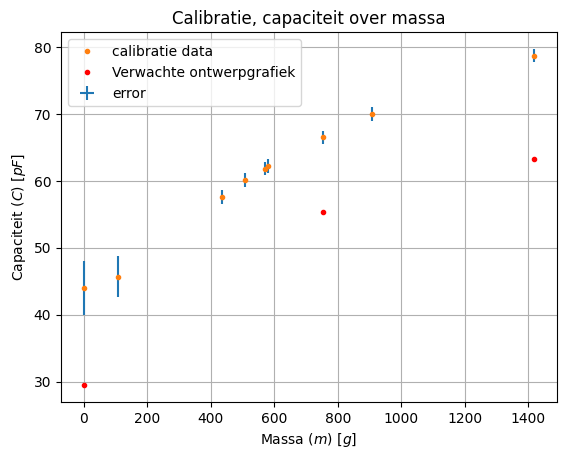

In [54]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

massa_array = np.array([0,109,436,508,570,581,754,907,1418])
capaciteit_array = np.array([44,45.7,57.6,60.1,61.8,62.2,66.5,70,78.7])
u_massa = 0.5
u_capaciteit = np.array([4,3,1,1,1,1,1,1,1])

plt.figure()
plt.errorbar(massa_array,capaciteit_array,xerr=u_massa,yerr=u_capaciteit, label="error", linestyle= "None")
plt.plot(massa_array,capaciteit_array,".", label="calibratie data")
plt.plot(m, C * 1e12, 'r.', label="Verwachte ontwerpgrafiek")
plt.title("Calibratie, capaciteit over massa")
plt.xlabel(r"Massa ($m$) [$g$]")
plt.ylabel(r"Capaciteit ($C$) [$pF$]")
plt.legend()
plt.grid()
plt.show()


# en zet ook de verwachte ontwerpgrafiek erbij

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* verbetering 1
* verbetering 2

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](tudelftLogo.png)

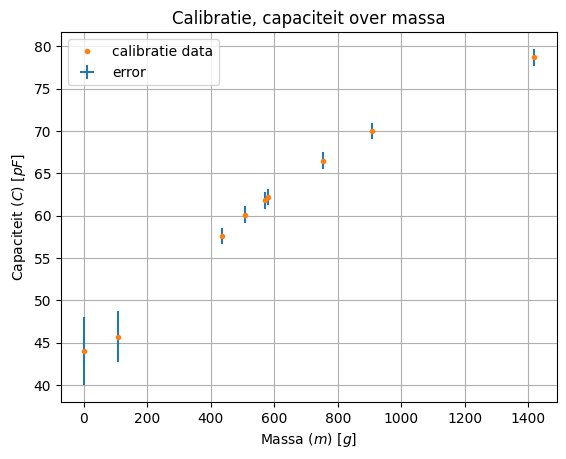

In [33]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door

from scipy.optimize import curve_fit

def functie_fit(x, a, b):
    return a * np.sqrt(x) + b

# values_1, cov_1 = curve_fit(functie_fit massa_array,)

massa_array = np.array([0,109,436,508,570,581,754,907,1418])
capaciteit_array = np.array([44,45.7,57.6,60.1,61.8,62.2,66.5,70,78.7])
u_massa = 0.5
u_capaciteit = np.array([4,3,1,1,1,1,1,1,1])

plt.figure()
plt.errorbar(massa_array,capaciteit_array,xerr=u_massa,yerr=u_capaciteit, label="error", linestyle= "None")
plt.plot(massa_array,capaciteit_array,".", label="calibratie data")
plt.plot(m, C * 1e12, 'r.', label="Verwachte ontwerpgrafiek")
plt.title("Calibratie, capaciteit over massa")
plt.xlabel(r"Massa ($m$) [$g$]")
plt.ylabel(r"Capaciteit ($C$) [$pF$]")
plt.legend()
plt.grid()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

Vul hier de conclusie in

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.